Les features du dataset:

- InvoiceNo:	N° de facture
- StockCode:	Code produit (5 chiffres)
- Description:	Nom du produit
- Quantity:	Quantité
- InvoiceDate:	Date et heure
- UnitPrice:	Prix unitaire en livres (£)
- CustomerID:	Identifiant client
- Country:	Pays du client (~91 % UK, ~37 pays)


In [2]:
import pandas as pd

In [3]:
df_a = pd.read_excel("C:/Users/User1/Desktop/TAISS2026/online_retail_II.xlsx", sheet_name="Year 2009-2010")
df_b = pd.read_excel("C:/Users/User1/Desktop/TAISS2026/online_retail_II.xlsx", sheet_name="Year 2010-2011")

In [4]:
df = pd.concat([df_a, df_b], ignore_index=True)

In [5]:
df.shape

(1067371, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


# ce dataset contient 525461 ligne et 8 colonnes et on a des valeurs nuls au niveau de Description, Customer ID

In [7]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [32]:
n_brut = len(df)

In [9]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [10]:
df[df.duplicated()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067136,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
1067150,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
1067153,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
1067160,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


nous avons supprimer les lignes vide de la colonne Custumer ID car Transaction inexploitable pour le RFM.

In [11]:
df = df.dropna(subset=['Customer ID'])

In [12]:
df.isna().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [13]:
import matplotlib.pyplot as plt

Suppression des doublons

In [14]:
df= df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [57]:
df2 = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [58]:
n_propre = len(df2)
print(f"Nettoyage : {n_brut} -> {n_propre} lignes ({100*(n_brut-n_propre)/n_brut:.1f}% retirées)")

Nettoyage : 797885 -> 779425 lignes (2.3% retirées)


In [59]:
df2['TotalPrice'] = df2['Quantity'] * df2['Price']

In [30]:
df2.describe()

,Quantity,InvoiceDate,Price,Customer ID,TotalPrice
count,779425.000000,779425,779425.000000,779425.000000,779425.000000
mean,13.489370,2011-01-03 01:44:42.593476,3.218488,15320.360461,22.291823
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000
25%,2.000000,2010-07-02 14:39:00,1.250000,13971.000000,4.950000
50%,6.000000,2010-12-02 14:09:00,1.950000,15247.000000,12.480000
75%,12.000000,2011-08-01 13:44:00,3.750000,16794.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,10953.500000,18287.000000,168469.600000
std,145.855814,NaN,29.676140,1695.692775,227.427075


In [60]:
df2.shape

(779425, 9)

In [18]:
df2.info()

<class 'pandas.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779495 non-null  object        
 1   StockCode    779495 non-null  object        
 2   Description  779495 non-null  object        
 3   Quantity     779495 non-null  int64         
 4   InvoiceDate  779495 non-null  datetime64[us]
 5   Price        779495 non-null  float64       
 6   Customer ID  779495 non-null  float64       
 7   Country      779495 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 63.5+ MB


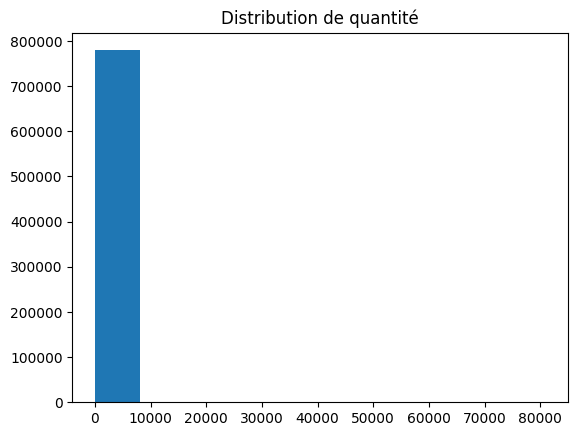

In [19]:
plt.hist(df2['Quantity'])
plt.title("Distribution de quantité")
plt.show()

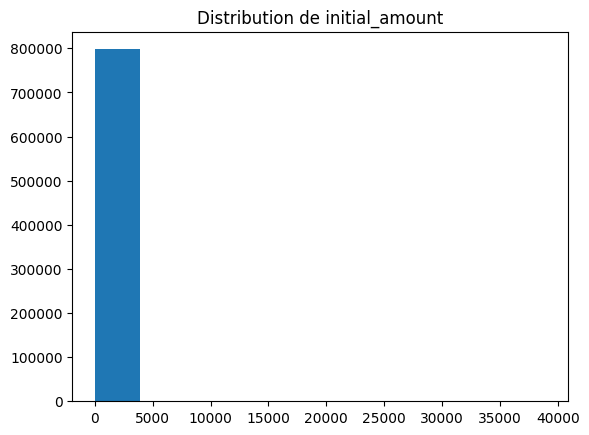

In [20]:
plt.hist(df['Price'])
plt.title("Distribution de initial_amount")
plt.show()

# RFM et transformation

In [ ]:
date_reference = df2['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df2.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (date_reference - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm.describe())

        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    2955.904095
std     1715.572666   209.338707    13.009406   14440.852688
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     342.280000
50%    15314.500000    96.000000     3.000000     867.740000
75%    16797.750000   380.000000     7.000000    2248.305000
max    18287.000000   739.000000   398.000000  580987.040000


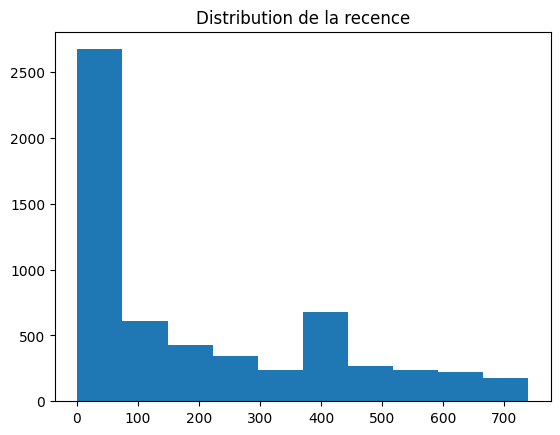

In [45]:
# distribution de ls recence
plt.hist(rfm['Recency'])
plt.title("Distribution de la recence")
plt.show()

La distribution de la recence est asymetrique, la plupart des transactions sont recente et tres dense entre 0 et 100 jours

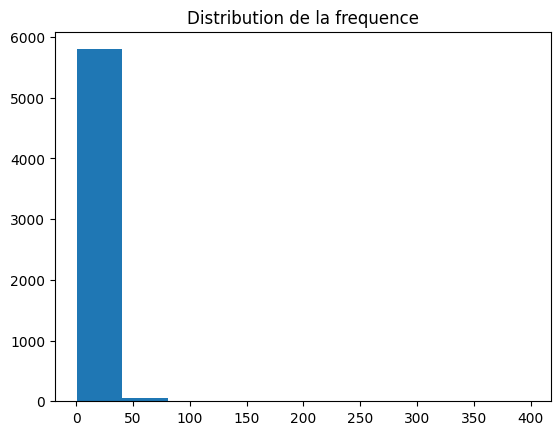

In [44]:
# distribution de ls recence
plt.hist(rfm['Frequency'])
plt.title("Distribution de la frequence")
plt.show()

la frequence des achats est tres dense entre 0 et 50


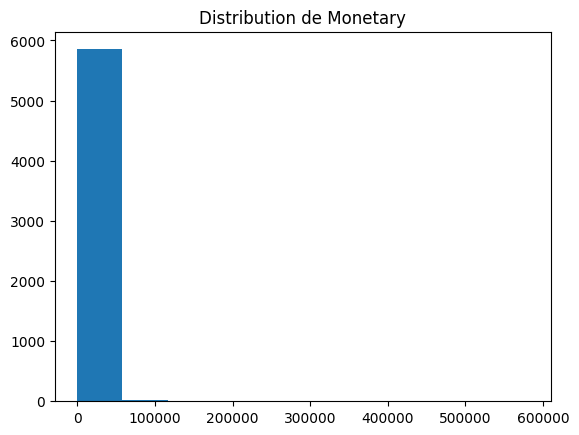

In [ ]:
# distribution de monetary
plt.hist(rfm['Monetary'])
plt.title("Distribution de Monetary")
plt.show()

In [47]:
def afficher_correlations(caracteristiques: pd.DataFrame) -> None:
    correlation = caracteristiques.corr()
    plt.figure(figsize=(5, 4))
    plt.imshow(correlation, cmap="Reds")
    plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
    plt.yticks(range(len(correlation.columns)), correlation.columns)
    plt.colorbar()
    plt.title("Correlation entre les variables")
    plt.tight_layout()
    plt.show()

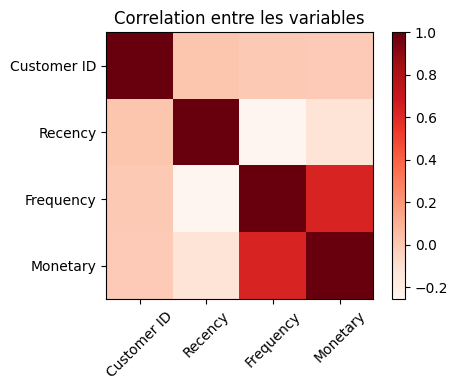

In [56]:
afficher_correlations(rfm)

- la variable frequency et monetary sont tres fortement correle

# recherche du nombre de k ppour le kmeans

In [49]:
import numpy as np
from sklearn.preprocessing import StandardScaler

Asymétrie (skew) avant transformation :
Recency       0.887198
Frequency    12.639951
Monetary     25.070190
dtype: float64
Asymétrie (skew) après log1p :
Recency     -0.488631
Frequency    1.001471
Monetary     0.269125
dtype: float64


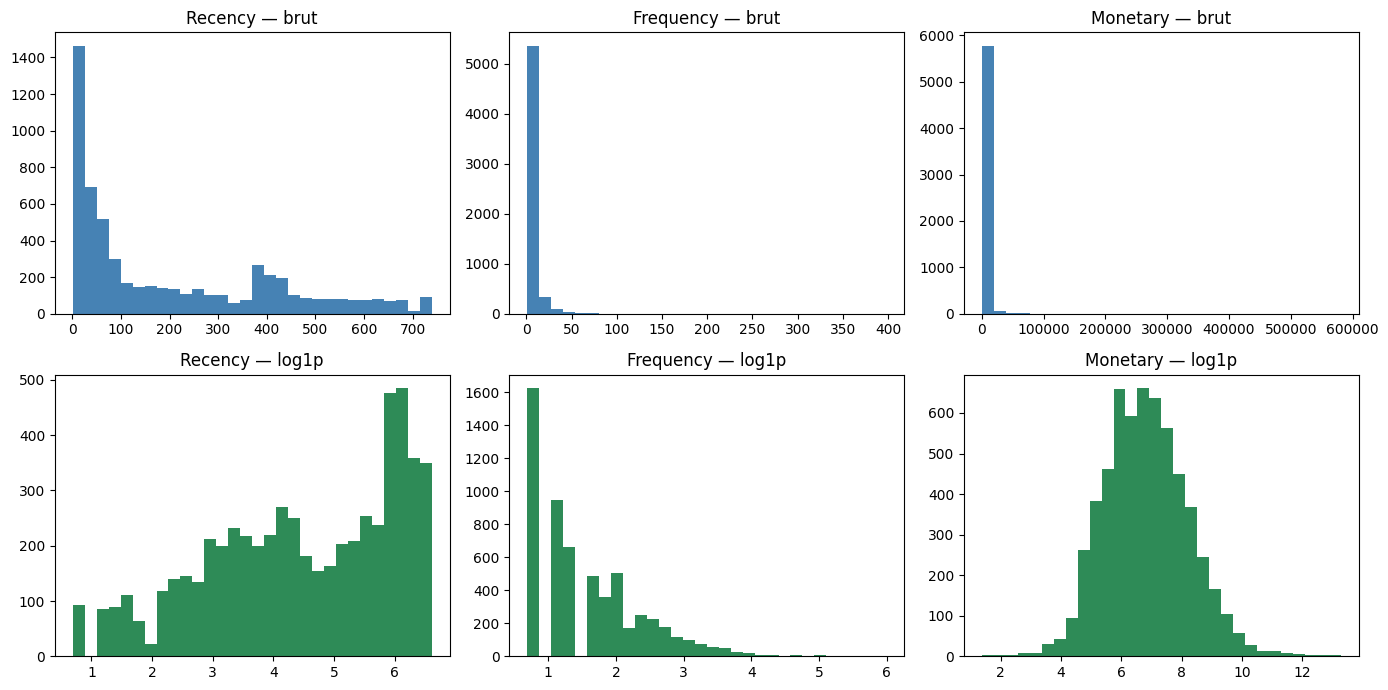

In [51]:
print("Asymétrie (skew) avant transformation :")
print(rfm[['Recency', 'Frequency', 'Monetary']].skew())

rfm_log = rfm.copy()
for col in ['Recency', 'Frequency', 'Monetary']:
    rfm_log[col] = np.log1p(rfm_log[col])  # log1p : gère aussi les valeurs à 0

print("Asymétrie (skew) après log1p :")
print(rfm_log[['Recency', 'Frequency', 'Monetary']].skew())

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[0, i].hist(rfm[col], bins=30, color='steelblue')
    axes[0, i].set_title(f'{col} — brut')
    axes[1, i].hist(rfm_log[col], bins=30, color='seagreen')
    axes[1, i].set_title(f'{col} — log1p')
plt.tight_layout()
plt.savefig('distributions_rfm.png', dpi=120)
plt.show()

scaler = StandardScaler()
X = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])
